# Lab 02 - Data Understanding: Global Urban Air Quality and Pollution Time-Series

This notebook applies **Lab 2 - Data Understanding** to the assignment dataset. The goal is to become familiar with the data through dataframe inspection, category counts, and visual exploration.


## Lab 2 concepts used

- Import pandas, seaborn, matplotlib, and warnings.
- Use `head()` and `tail()` to inspect rows.
- Use `value_counts()` to understand important categories or labels.
- Create scatter, jointplot, hue-based scatter, boxplot, stripplot, KDE, pairplot, grouped boxplot, and radviz visualizations where suitable for the dataset.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'AML Assignment' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT


WindowsPath('D:/APU Study/1st Semester/Applied Machine Learning/AML Assignment')

In [3]:
DATASET_FILENAME = 'global_urban_smog_pm25_hourly.csv'
matches = sorted((PROJECT_ROOT / 'Datasets').glob(f'*/{DATASET_FILENAME}'))
if not matches:
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME} under {PROJECT_ROOT / "Datasets"}')
DATASET_PATH = matches[0]
data = pd.read_csv(DATASET_PATH)
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hazardous_Event_Label'] = data['Hazardous_Event'].map({0: 'Not hazardous', 1: 'Hazardous'})
data.head()


,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event,Hazardous_Event_Label
0,2025-05-22 00:00:00,Lahore,31.5204,74.3587,186.7,74.3,926.0,22.9,94.0,197.0,0.0,76,0,Not hazardous
1,2025-05-22 01:00:00,Lahore,31.5204,74.3587,286.8,96.4,736.0,18.1,103.0,356.0,0.0,77,0,Not hazardous
2,2025-05-22 02:00:00,Lahore,31.5204,74.3587,380.0,122.0,599.0,14.1,110.0,506.0,0.0,78,0,Not hazardous
3,2025-05-22 03:00:00,Lahore,31.5204,74.3587,486.2,149.9,548.0,11.7,114.0,640.0,0.0,80,0,Not hazardous
4,2025-05-22 04:00:00,Lahore,31.5204,74.3587,581.1,172.8,550.0,10.1,118.0,765.0,0.0,85,0,Not hazardous


In [4]:
data.tail()


,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event,Hazardous_Event_Label
254731,2026-05-22 19:00:00,Buenos Aires,-34.6037,-58.3816,19.0,15.3,215.0,36.1,15.0,0.0,0.0,31,0,Not hazardous
254732,2026-05-22 20:00:00,Buenos Aires,-34.6037,-58.3816,19.5,15.8,201.0,40.1,11.0,0.0,0.0,30,0,Not hazardous
254733,2026-05-22 21:00:00,Buenos Aires,-34.6037,-58.3816,19.7,15.9,181.0,41.6,9.0,0.0,0.0,29,0,Not hazardous
254734,2026-05-22 22:00:00,Buenos Aires,-34.6037,-58.3816,19.4,15.5,151.0,39.1,10.0,0.0,0.0,29,0,Not hazardous
254735,2026-05-22 23:00:00,Buenos Aires,-34.6037,-58.3816,18.8,15.0,114.0,34.0,14.0,0.0,0.0,28,0,Not hazardous


In [5]:
print('Shape:', data.shape)
print('Columns:')
for column in data.columns:
    print('-', column)


Shape: (254736, 14)
Columns:
- Timestamp
- City
- Latitude
- Longitude
- PM10_ug_m3
- PM2_5_ug_m3
- Carbon_Monoxide_ug_m3
- Nitrogen_Dioxide_ug_m3
- Ozone_ug_m3
- Dust_ug_m3
- UV_Index
- European_AQI
- Hazardous_Event
- Hazardous_Event_Label


In [6]:
print('\nValue counts for City')
display(data['City'].value_counts(dropna=False).head(15))

print('\nValue counts for Hazardous_Event')
display(data['Hazardous_Event'].value_counts(dropna=False).head(15))



Value counts for City


City
Lahore         8784
Delhi          8784
Beijing        8784
Los Angeles    8784
London         8784
Mumbai         8784
New York       8784
Tokyo          8784
Dhaka          8784
Jakarta        8784
Karachi        8784
Seoul          8784
Mexico City    8784
Sao Paulo      8784
Cairo          8784
Name: count, dtype: int64


Value counts for Hazardous_Event


Hazardous_Event
0    221074
1     33662
Name: count, dtype: int64

## Dataset-adapted Lab 2 visualizations

The original Lab 2 notebook uses Iris features such as sepal length, sepal width, petal length, and species. The cells below keep the same visualization ideas, but use columns that make sense for this dataset.


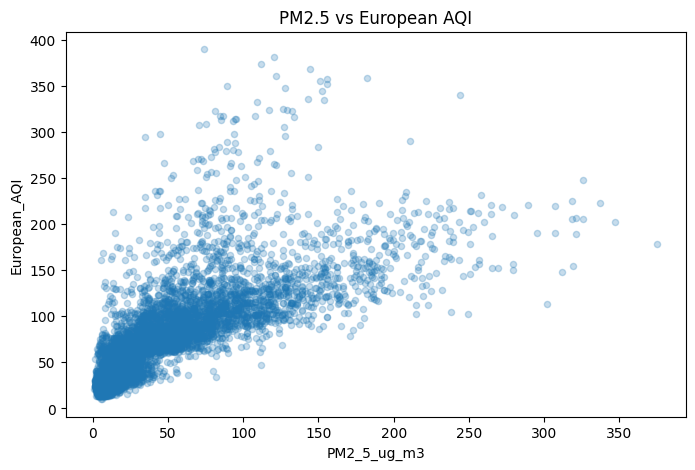

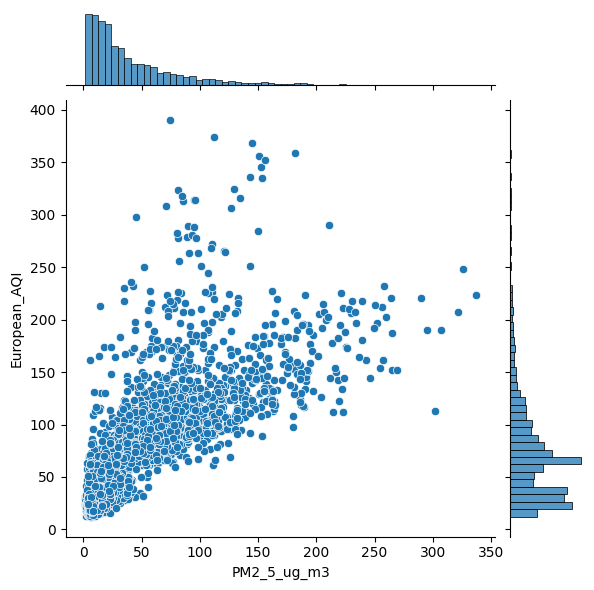

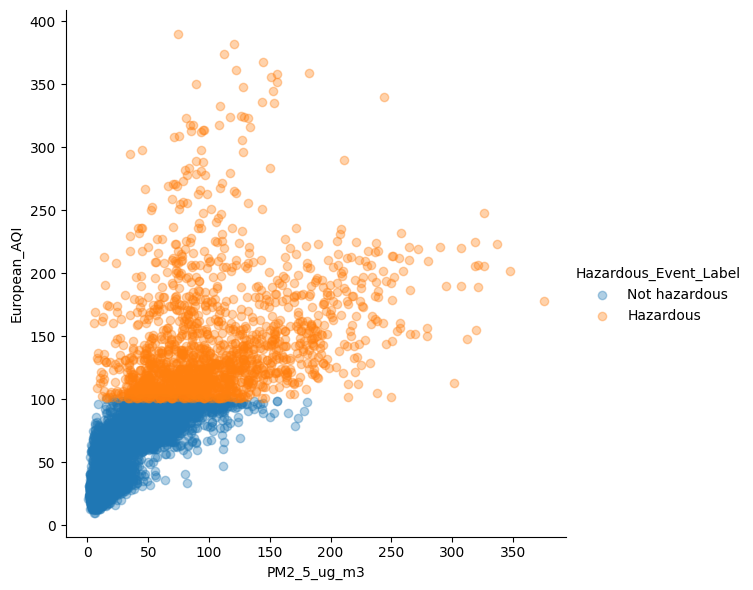

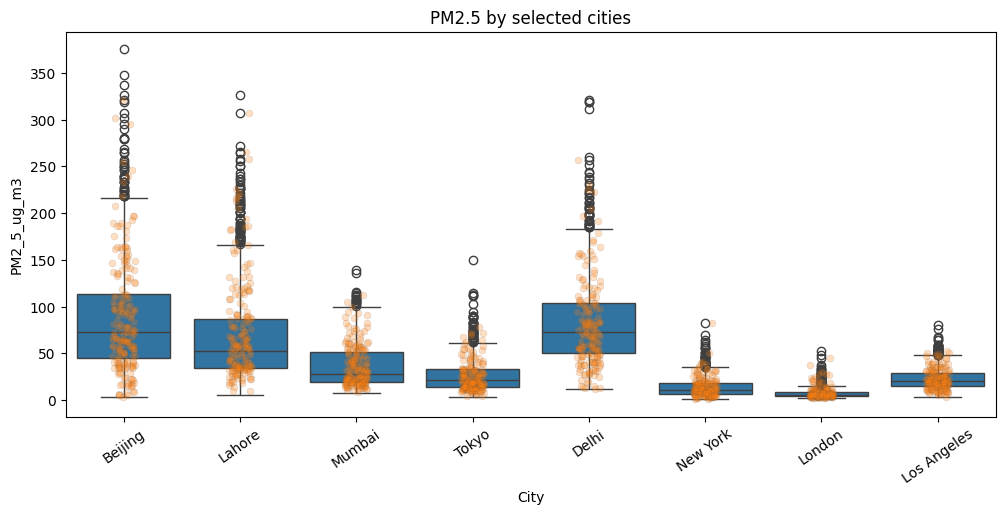

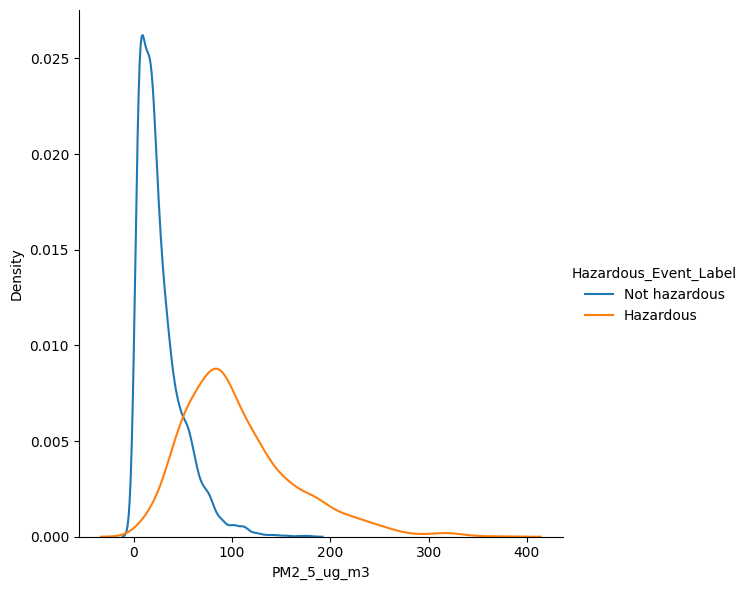

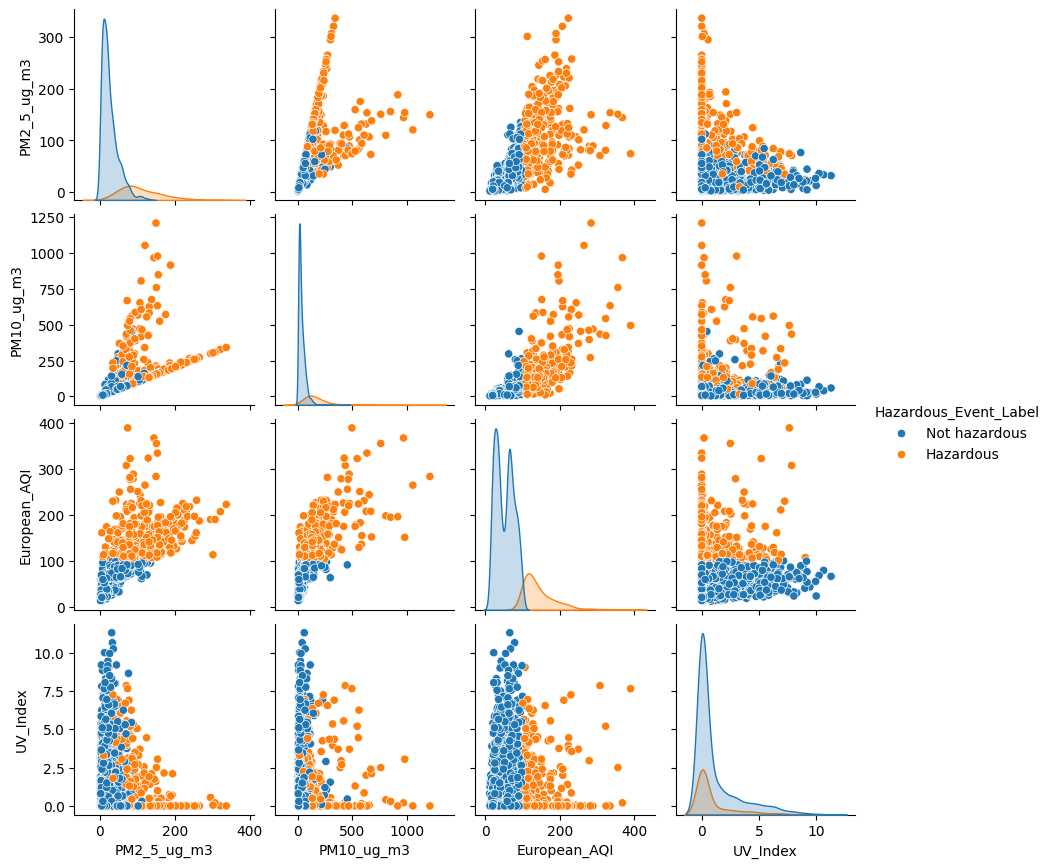

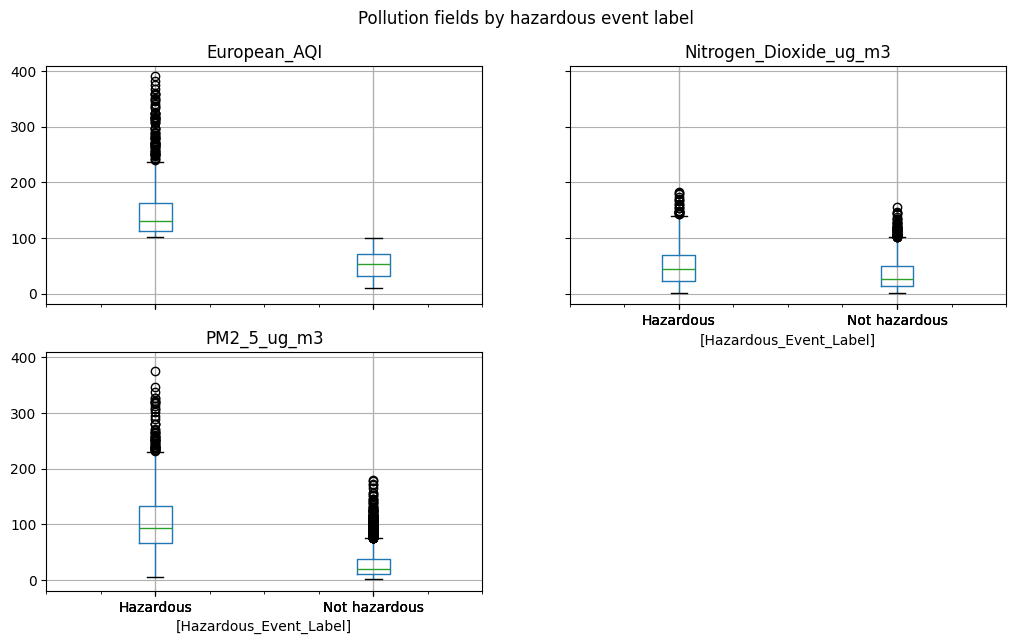

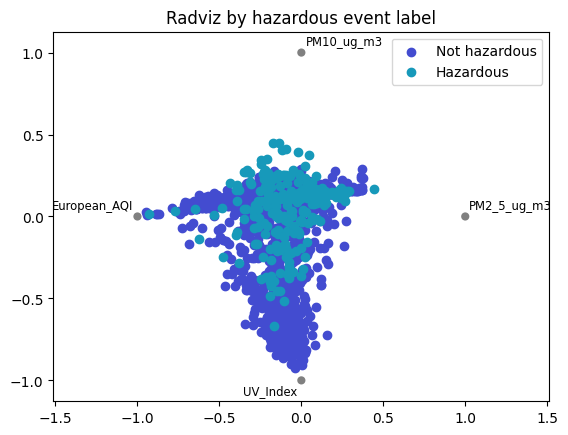

In [7]:
selected_cities = data['City'].value_counts().head(8).index
city_df = data[data['City'].isin(selected_cities)].copy()
plot_df = city_df.sample(n=min(8000, len(city_df)), random_state=42)

plot_df.plot(kind='scatter', x='PM2_5_ug_m3', y='European_AQI', alpha=0.25, figsize=(8, 5), title='PM2.5 vs European AQI')
plt.show()

sns.jointplot(x='PM2_5_ug_m3', y='European_AQI', data=plot_df.sample(n=min(4000, len(plot_df)), random_state=42), height=6)
plt.show()

sns.FacetGrid(plot_df, hue='Hazardous_Event_Label', height=6).map(plt.scatter, 'PM2_5_ug_m3', 'European_AQI', alpha=0.35).add_legend()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='City', y='PM2_5_ug_m3', data=plot_df)
sns.stripplot(x='City', y='PM2_5_ug_m3', data=plot_df.sample(n=min(1500, len(plot_df)), random_state=42), jitter=True, edgecolor='gray', linewidth=0.3, alpha=0.25)
plt.title('PM2.5 by selected cities')
plt.xticks(rotation=35)
plt.show()

sns.FacetGrid(plot_df, hue='Hazardous_Event_Label', height=6).map(sns.kdeplot, 'PM2_5_ug_m3').add_legend()
plt.show()

pair_cols = ['PM2_5_ug_m3', 'PM10_ug_m3', 'European_AQI', 'UV_Index', 'Hazardous_Event_Label']
sns.pairplot(plot_df[pair_cols].dropna().sample(n=min(2000, len(plot_df)), random_state=42), hue='Hazardous_Event_Label', height=2.2, diag_kind='kde')
plt.show()

box_cols = ['Hazardous_Event_Label', 'PM2_5_ug_m3', 'European_AQI', 'Nitrogen_Dioxide_ug_m3']
plot_df[box_cols].dropna().boxplot(by='Hazardous_Event_Label', figsize=(12, 7))
plt.suptitle('Pollution fields by hazardous event label')
plt.show()

from pandas.plotting import radviz
radviz_cols = ['PM2_5_ug_m3', 'PM10_ug_m3', 'European_AQI', 'UV_Index', 'Hazardous_Event_Label']
radviz(plot_df[radviz_cols].dropna().sample(n=min(1500, len(plot_df)), random_state=42), 'Hazardous_Event_Label')
plt.title('Radviz by hazardous event label')
plt.show()


## What was learned from Lab 2

These plots give an initial view of distributions, category balance, relationships between numeric fields, and possible separation by important labels or groups. No preprocessing or machine learning model is applied yet; that begins from Lab 3 onward.
